**Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


In [ ]:
df = pd.read_excel('Cotton_Farming_Yield.xlsx')
df.head()


,_heat_waves,"_floods_(river,_rain",moonsoon,drought,_smog,air_pollution_damage,hailstorm,prolonged_winter,other_-_please_speci,_delayed_sowing,...,use_of_organic_plant_2,use_of_mechanical_ma_2,manual_weeding_2,pest_scouting_on_reg_2,use_of_biopesticides_2,use_of_living_organi_2,use_of_trap_crops_to_2,pheromone_trap_for_i,yield_of_cotton_per_,yield_of_cotton_per__2
0,1,1,1,1,1,1,1,1,0,1,...,1,1,1,1,1,1,0,0,23,20
1,1,0,0,0,0,1,1,1,0,1,...,0,1,1,1,1,0,0,0,20,20
2,1,0,0,1,0,1,0,1,0,1,...,1,1,1,0,0,0,0,0,18,18
3,1,0,1,1,1,1,0,1,0,1,...,0,1,1,0,1,0,0,0,20,24
4,1,0,0,1,1,1,0,0,0,1,...,1,0,0,0,1,0,0,0,6,6


In [ ]:
df.shape

(449, 106)

##**Data Exploration**

**Data Types**

In [ ]:
# Examine data types
data_types = df.dtypes
print("Data Types:\n", data_types)

Data Types:
 _heat_waves               int64
_floods_(river,_rain      int64
moonsoon                  int64
drought                   int64
_smog                     int64
                          ...  
use_of_living_organi_2    int64
use_of_trap_crops_to_2    int64
pheromone_trap_for_i      int64
yield_of_cotton_per_      int64
yield_of_cotton_per__2    int64
Length: 106, dtype: object


**Examine missing values**

In [ ]:
# Examine missing values
missing_values= df.isnull().sum()
missing_values

,0
_heat_waves,0
"_floods_(river,_rain",0
moonsoon,0
drought,0
_smog,0
...,...
use_of_living_organi_2,0
use_of_trap_crops_to_2,0
pheromone_trap_for_i,0
yield_of_cotton_per_,0


In [ ]:
missing_percentage = (missing_values / len(df)) * 100
print("\nMissing Value Percentage:\n", missing_percentage)


Missing Value Percentage:
 _heat_waves               0.0
_floods_(river,_rain      0.0
moonsoon                  0.0
drought                   0.0
_smog                     0.0
                         ... 
use_of_living_organi_2    0.0
use_of_trap_crops_to_2    0.0
pheromone_trap_for_i      0.0
yield_of_cotton_per_      0.0
yield_of_cotton_per__2    0.0
Length: 106, dtype: float64


**Summarize numerical features**

In [ ]:
# Summarize numerical features
df.describe()

,_heat_waves,"_floods_(river,_rain",moonsoon,drought,_smog,air_pollution_damage,hailstorm,prolonged_winter,other_-_please_speci,_delayed_sowing,...,use_of_organic_plant_2,use_of_mechanical_ma_2,manual_weeding_2,pest_scouting_on_reg_2,use_of_biopesticides_2,use_of_living_organi_2,use_of_trap_crops_to_2,pheromone_trap_for_i,yield_of_cotton_per_,yield_of_cotton_per__2
count,449.000000,449.000000,449.000000,449.00000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,...,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000,449.000000
mean,0.948775,0.365256,0.587973,0.30735,0.389755,0.244989,0.222717,0.483296,0.008909,0.498886,...,0.463252,0.347439,0.601336,0.478842,0.184855,0.060134,0.026726,0.017817,22.053452,23.703786
std,0.220702,0.482039,0.492749,0.46191,0.488239,0.430560,0.416534,0.500278,0.094069,0.500556,...,0.499204,0.476688,0.490169,0.500109,0.388613,0.237999,0.161462,0.132435,9.605699,9.044237
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,16.000000
50%,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22.000000,25.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,29.000000,30.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,55.000000,55.000000


**Explore categorical features**

In [ ]:
# Explore categorical features
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_summary = {}
for col in categorical_cols:
    categorical_summary[col] = df[col].value_counts()

print("\nCategorical Summary:\n", categorical_summary)


Categorical Summary:
 {'7._do_you_think_for_': 7._do_you_think_for_
2                                         121
5                                         107
3                                          80
4                                          50
1                                          25
6                                          24
7                                          13
0                                          10
8                                           7
Don’t k0w                                   5
10                                          2
For life                                    1
20                                          1
For years for the betterment of cotton      1
Don’t K0w                                   1
2\n                                         1
Name: count, dtype: int64}


**Check Duplicates**

In [ ]:
# Check for duplicates
duplicate_rows = df[df.duplicated()]
num_duplicates = len(duplicate_rows)
print("\nNumber of Duplicate Rows:", num_duplicates)


Number of Duplicate Rows: 0


**Initial outlier detection (numerical features only)**

In [ ]:
# Initial outlier detection (numerical features only)
numerical_cols = df.select_dtypes(include=['number']).columns
outlier_summary = {}
for col in numerical_cols:
  outlier_summary[col] = {
      'min': df[col].min(),
      'max': df[col].max()
  }

print("\nPotential Outliers (min/max):\n", outlier_summary)


Potential Outliers (min/max):
 {'_heat_waves': {'min': 0, 'max': 1}, '_floods_(river,_rain': {'min': 0, 'max': 1}, 'moonsoon': {'min': 0, 'max': 1}, 'drought': {'min': 0, 'max': 1}, '_smog': {'min': 0, 'max': 1}, 'air_pollution_damage': {'min': 0, 'max': 1}, 'hailstorm': {'min': 0, 'max': 1}, 'prolonged_winter': {'min': 0, 'max': 1}, 'other_-_please_speci': {'min': 0, 'max': 1}, '_delayed_sowing': {'min': 0, 'max': 1}, '_delayed_picking': {'min': 0, 'max': 1}, '_increased_attack_of': {'min': 0, 'max': 1}, '_increased_attack_of_2': {'min': 0, 'max': 1}, '_increased_spread_of': {'min': 0, 'max': 1}, 'damage_to_crop_by_ra': {'min': 0, 'max': 1}, '_reduced_yield': {'min': 0, 'max': 1}, 'reduced_quality_of_p': {'min': 0, 'max': 1}, '_delayed_flowering_d': {'min': 0, 'max': 1}, '1._climate_smart_pra': {'min': 0, 'max': 1}, 'land_preparation_via': {'min': 0.0, 'max': 1.0}, 'rotation_of_cotton_c': {'min': 0.0, 'max': 1.0}, 'bed_sowing_of_cotton': {'min': 0.0, 'max': 1.0}, 'laser_land_levellin

In [ ]:
print("\nData Shape (rows, columns):", (df.shape))


Data Shape (rows, columns): (449, 106)


## **Data visualization**

### Subtask:
Visualize the distribution of key numerical features and explore relationships between features.


In [ ]:
# Select a few key numerical features for visualization
numerical_features = ['yield_of_cotton_per_', 'yield_of_cotton_per__2']  # Add more if needed

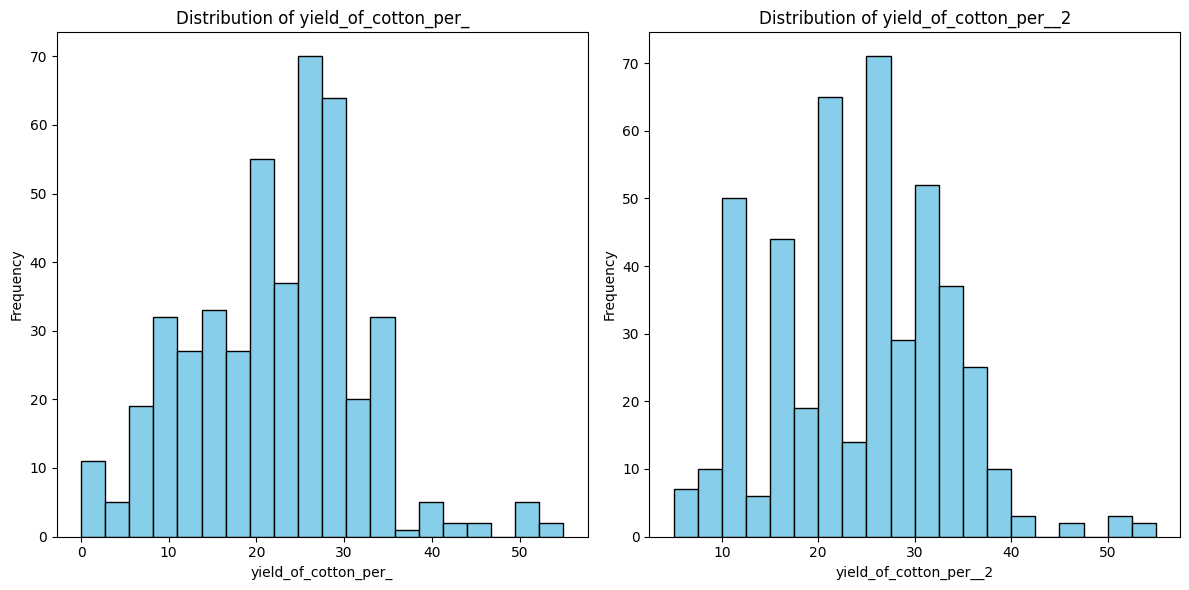

In [ ]:

# Create histograms
plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    plt.hist(df[feature], bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

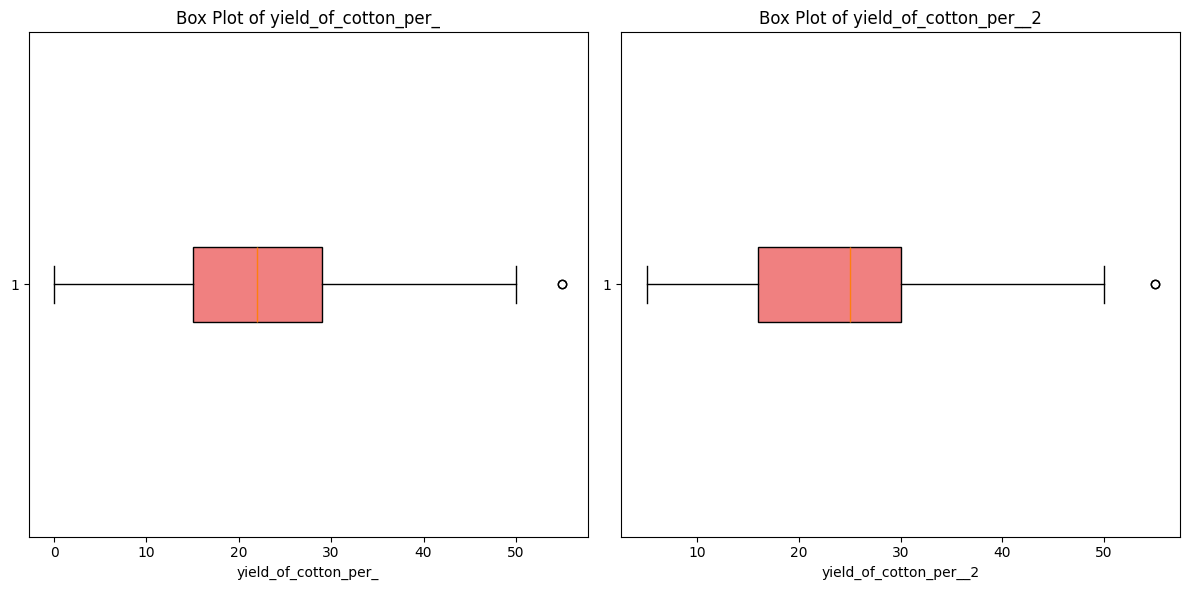

In [ ]:
# Create box plots
plt.figure(figsize=(12, 6))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    plt.boxplot(df[feature], vert=False, patch_artist=True, boxprops=dict(facecolor='lightcoral'))
    plt.title(f'Box Plot of {feature}')
    plt.xlabel(feature)
plt.tight_layout()
plt.show()

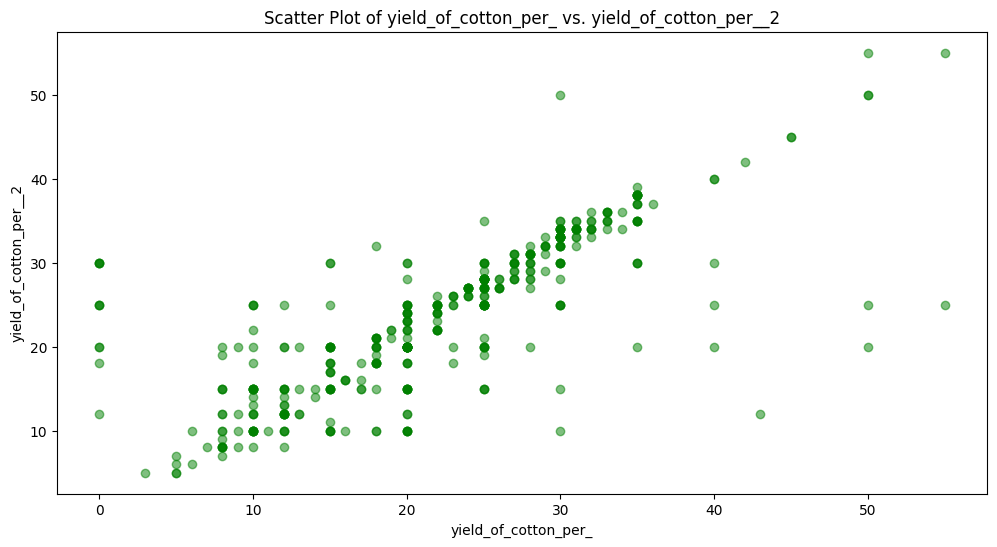

In [ ]:
# Create scatter plots
plt.figure(figsize=(12, 6))
for i in range(len(numerical_features)):
    for j in range(i + 1, len(numerical_features)):
        plt.scatter(df[numerical_features[i]], df[numerical_features[j]], color='green', alpha=0.5)
        plt.xlabel(numerical_features[i])
        plt.ylabel(numerical_features[j])
        plt.title(f'Scatter Plot of {numerical_features[i]} vs. {numerical_features[j]}')
        plt.show()

## Data analysis

### Subtask:
Analyze the relationships between different features in the dataset.


**Reasoning**:
Calculate the correlation matrix, identify highly correlated features, visualize the correlation matrix using a heatmap, and create scatter plots for highly correlated pairs.



In [ ]:
# Convert non-numeric columns to numeric, coercing errors to NaN
for col in df.columns:
    if not pd.api.types.is_numeric_dtype(df[col]):
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Set a threshold for high correlation
threshold = 0.7

# Find highly correlated features
highly_correlated_features = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_features.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))


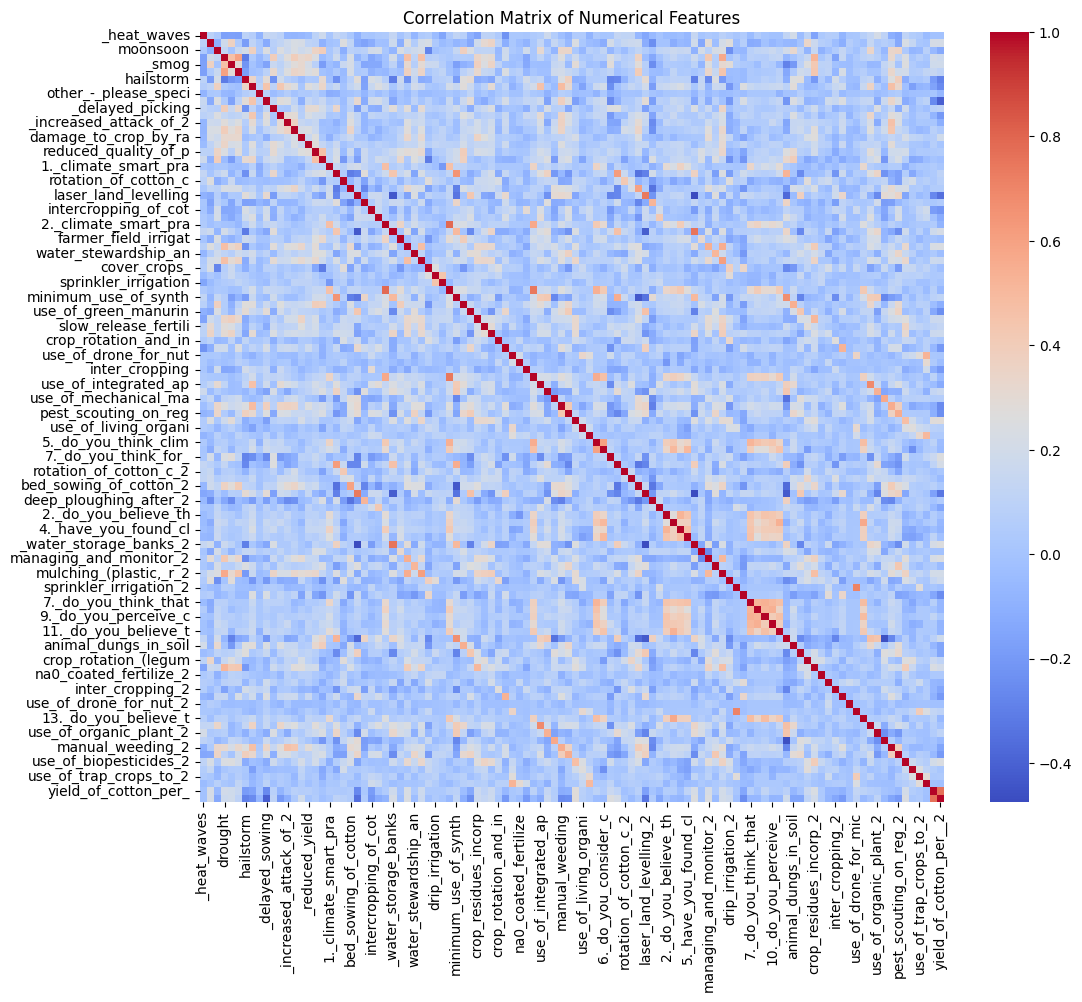

In [ ]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

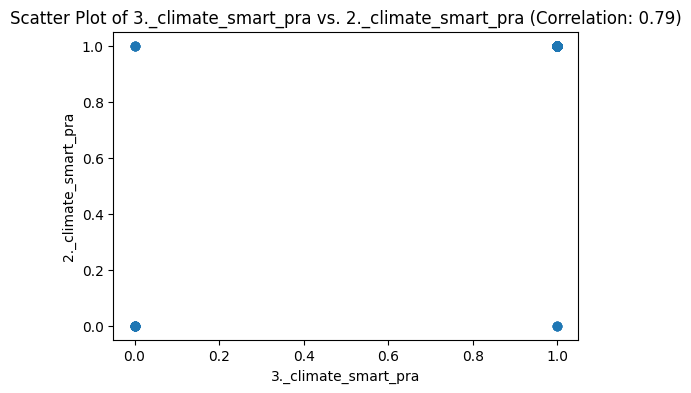

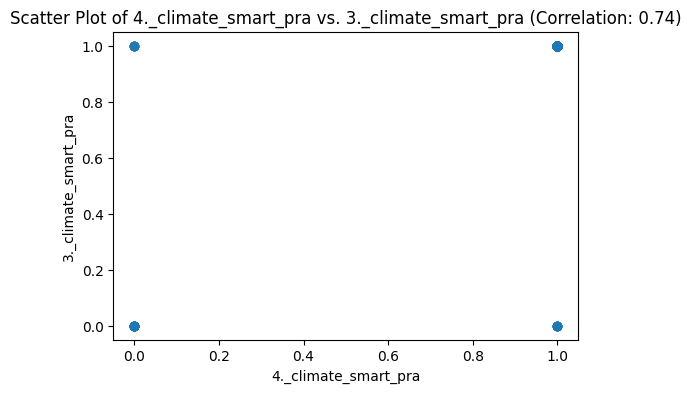

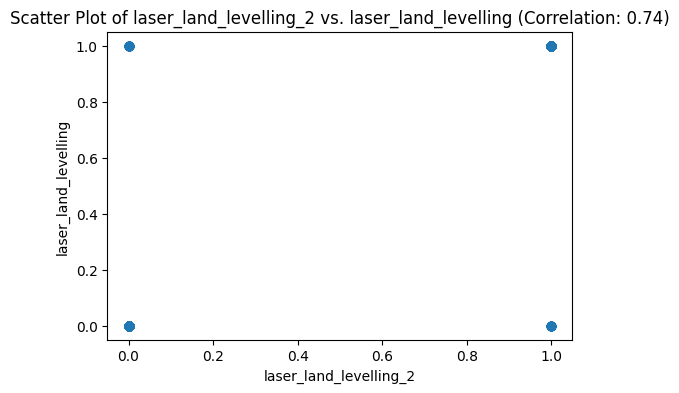

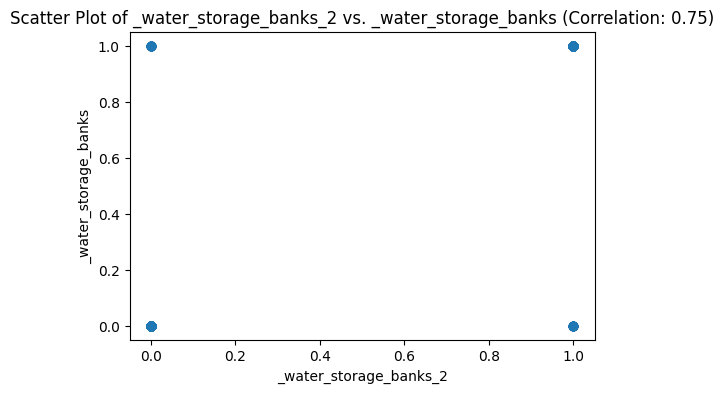

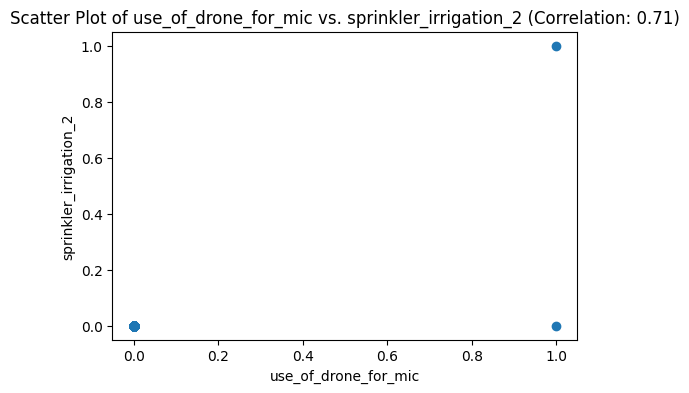

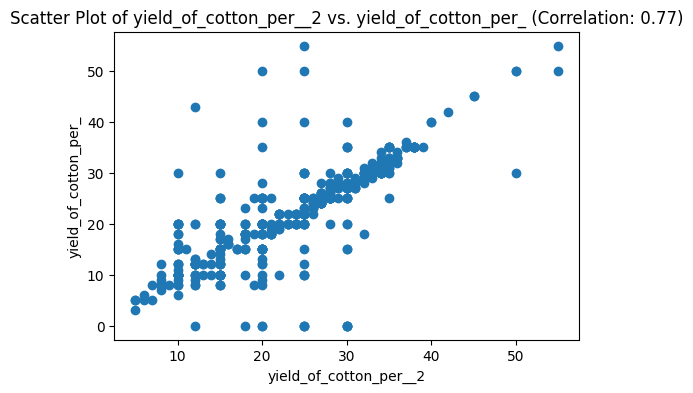

In [ ]:
# Create scatter plots for highly correlated feature pairs
for feature1, feature2, correlation in highly_correlated_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feature1], df[feature2])
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f'Scatter Plot of {feature1} vs. {feature2} (Correlation: {correlation:.2f})')
    plt.show()

**Reasoning**:
The error message indicates that some values in the DataFrame cannot be converted to floats, likely because they are strings.  We need to identify and handle these non-numeric values before calculating the correlation matrix.



# **Relationship**

In [ ]:
# Create total yield column
df['total_yield'] = df['yield_of_cotton_per_'] + df['yield_of_cotton_per__2']

# Select only numeric features
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation with total_yield
correlation = numeric_df.corr()['total_yield'].drop('total_yield')

**Values of Correlation**

In [ ]:
# Round correlation values to 2 decimal places
rounded_corr = correlation.round(2)

# Count how many features have each rounded correlation value
correlation_counts = rounded_corr.value_counts().sort_index(ascending=False)
correlation_counts


,count
total_yield,
0.94,2
0.30,1
0.25,3
0.24,1
0.23,2
0.22,2
0.21,1
0.20,2
0.18,3


**Total Number of Positive and Negtive Correlation**

Total number of features which have Positive correlation > 0: 61
Total number of features which have Nagitive correlation < 0: 45
Total number of features which have 0 correlation = 0: 0


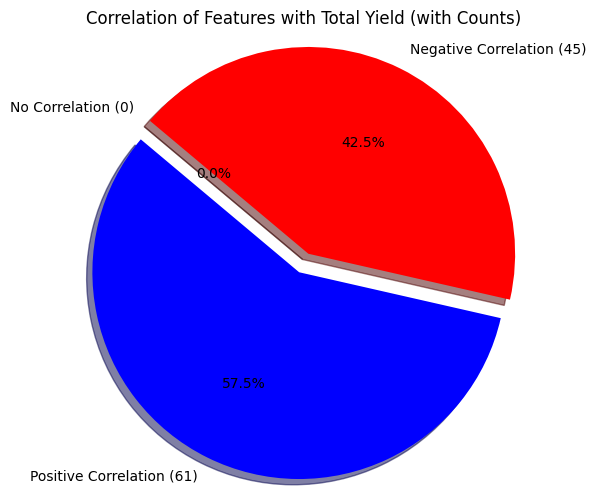

In [ ]:
# Count correlations
positive_corr_count = (correlation > 0).sum()
negative_corr_count = (correlation < 0).sum()
no_corr_count = (correlation == 0).sum()

print(f"Total number of features which have Positive correlation > 0: {positive_corr_count}")
print(f"Total number of features which have Nagitive correlation < 0: {negative_corr_count}")
print(f"Total number of features which have 0 correlation = 0: {no_corr_count}")

sizes = [positive_corr_count, negative_corr_count, no_corr_count]
labels = [
    f'Positive Correlation ({positive_corr_count})',
    f'Negative Correlation ({negative_corr_count})',
    f'No Correlation ({no_corr_count})'
]
colors = ['blue', 'Red', 'brown']
explode = (0.1, 0, 0)  # "Explode" the 1st slice

# Create pie chart
plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, explode=explode,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.title('Correlation of Features with Total Yield (with Counts)')
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular.
plt.show()


**Columns Name which have Positive correlation with total_yield:**

In [ ]:
# Get columns with negative correlation
Positive_corr_columns = correlation[correlation > 0]

# Print column names and their correlation values
print("Columns with Positive correlation with total_yield:")
print(Positive_corr_columns)


Columns with Positive correlation with total_yield:
_floods_(river,_rain      0.231964
drought                   0.196812
_smog                     0.199224
air_pollution_damage      0.133779
_delayed_picking          0.098896
                            ...   
use_of_biopesticides_2    0.237092
use_of_living_organi_2    0.040926
use_of_trap_crops_to_2    0.040121
yield_of_cotton_per_      0.944249
yield_of_cotton_per__2    0.936873
Name: total_yield, Length: 61, dtype: float64


**Columns Name which have negative correlation with total_yield:**

In [ ]:
# Get columns with negative correlation
negative_corr_columns = correlation[correlation < 0]

# Print column names and their correlation values
print("Columns with negative correlation with total_yield:")
print(negative_corr_columns)


Columns with negative correlation with total_yield:
_heat_waves              -0.011866
moonsoon                 -0.099648
hailstorm                -0.250699
prolonged_winter         -0.217024
other_-_please_speci     -0.033853
_delayed_sowing          -0.353224
_increased_attack_of     -0.144771
_increased_attack_of_2   -0.047662
_delayed_flowering_d     -0.010795
laser_land_levelling     -0.325965
intercropping_of_cot     -0.208352
conservation_tillage     -0.068863
2._climate_smart_pra     -0.020807
farmer_field_irrigat     -0.018907
water_stewardship_an     -0.000690
_animal_dungs_in_soi     -0.075135
use_of_green_manurin     -0.197447
use_of_4r_principal_     -0.136930
inter_cropping           -0.160144
use_of_integrated_ap     -0.085930
manual_weeding           -0.191609
pest_scouting_on_reg     -0.179870
6._do_you_consider_c     -0.001750
intercropping_of_cot_2   -0.017715
laser_land_levelling_2   -0.260726
conservation_tillage_2   -0.107900
3._do_you_perceive_c     -0.000750
4._

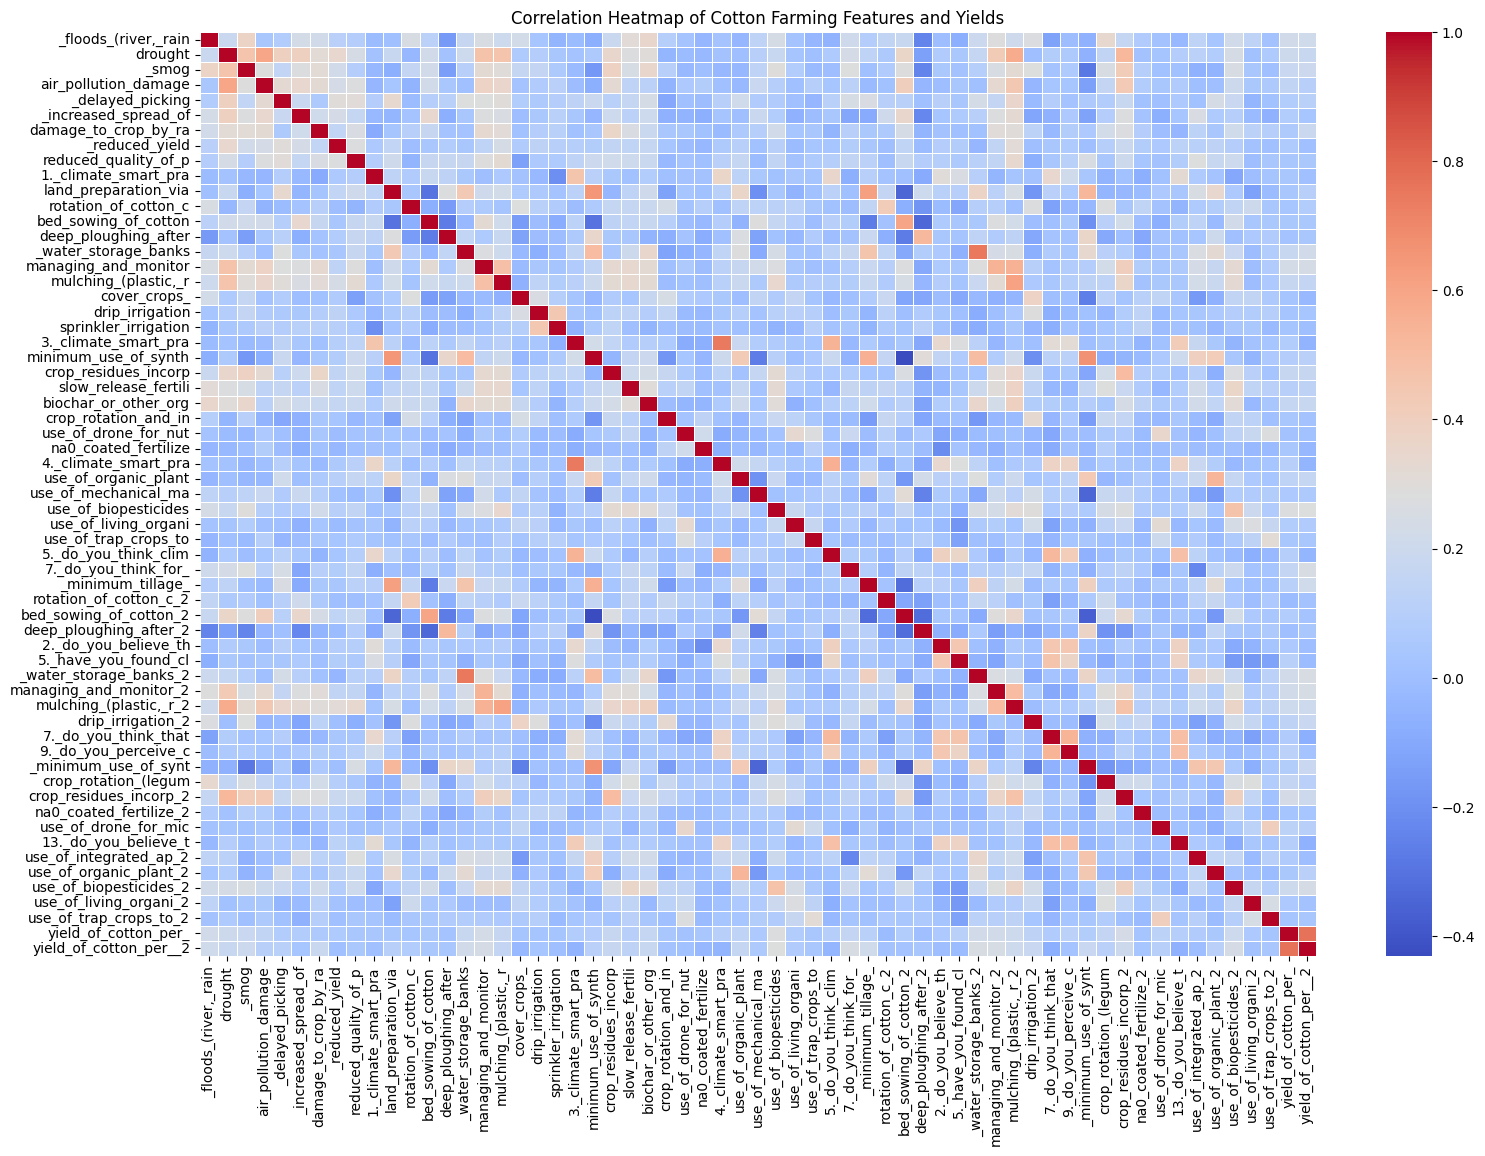

In [ ]:
# Compute correlation matrix
correlation_matrix = df[Positive_corr_columns.index].corr()

# Plot heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap of Cotton Farming Features and Yields")
plt.show()

## Summary:

### Q&A
No questions were asked in the provided text.

### Data Analysis Key Findings

* **Data Loading:** The dataset "Cotton_Farming_Yield.xlsx" was successfully loaded into a pandas DataFrame with 449 rows and 106 columns.
* **Data Exploration:**  No missing values were found across all 106 numerical columns. Duplicate rows were not present. Potential outliers were identified in each numerical column by examining their minimum and maximum values.
* **Data Visualization:** Histograms, box plots, and scatter plots were generated for the numerical features 'yield_of_cotton_per_' and 'yield_of_cotton_per__2', providing insights into their distributions and relationships, though the actual plots were not displayed in the output.
* **Data Analysis:**  Initially, non-numeric values prevented correlation matrix calculation.  These were converted to numeric, coercing errors to NaN. A correlation matrix was computed and visualized as a heatmap, revealing highly correlated feature pairs (threshold >0.7). Scatter plots were generated to visualize these relationships.


### Insights or Next Steps

* **Investigate Highly Correlated Features:**  Deep dive into the highly correlated feature pairs identified in the correlation analysis to understand the nature of their relationships and their potential impact on cotton yield prediction.
* **Feature Engineering:** Consider feature engineering based on the identified correlations.  Creating new features from combinations of highly correlated variables might improve model performance in subsequent predictive modeling tasks.


# **Feature Importance**

In [ ]:
# Define features and target
X = df.drop(columns=["yield_of_cotton_per_", "yield_of_cotton_per__2"])  # or your chosen target
y = df[['yield_of_cotton_per_', 'yield_of_cotton_per__2']]



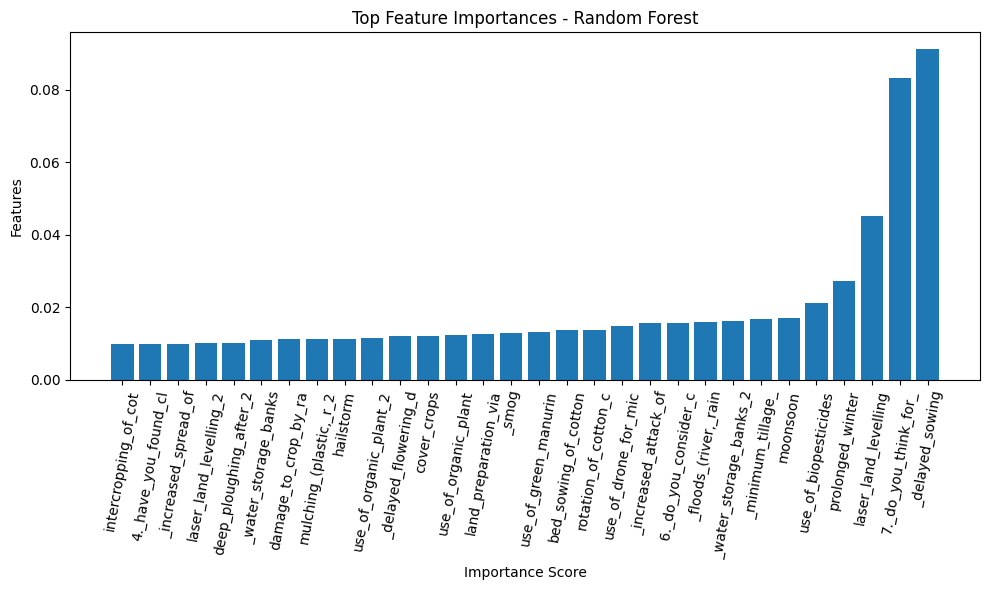

In [ ]:
# Train a model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Plot top 20 features
top_n = 30
indices = importances.argsort()[-top_n:]

plt.figure(figsize=(10, 6))
# Change here to provide height argument:
plt.bar(feature_names[indices], importances[indices])
plt.title("Top Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.xticks(rotation = 80)
plt.tight_layout()
plt.show()

<ipython-input-117-9dfc0155aa03>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")


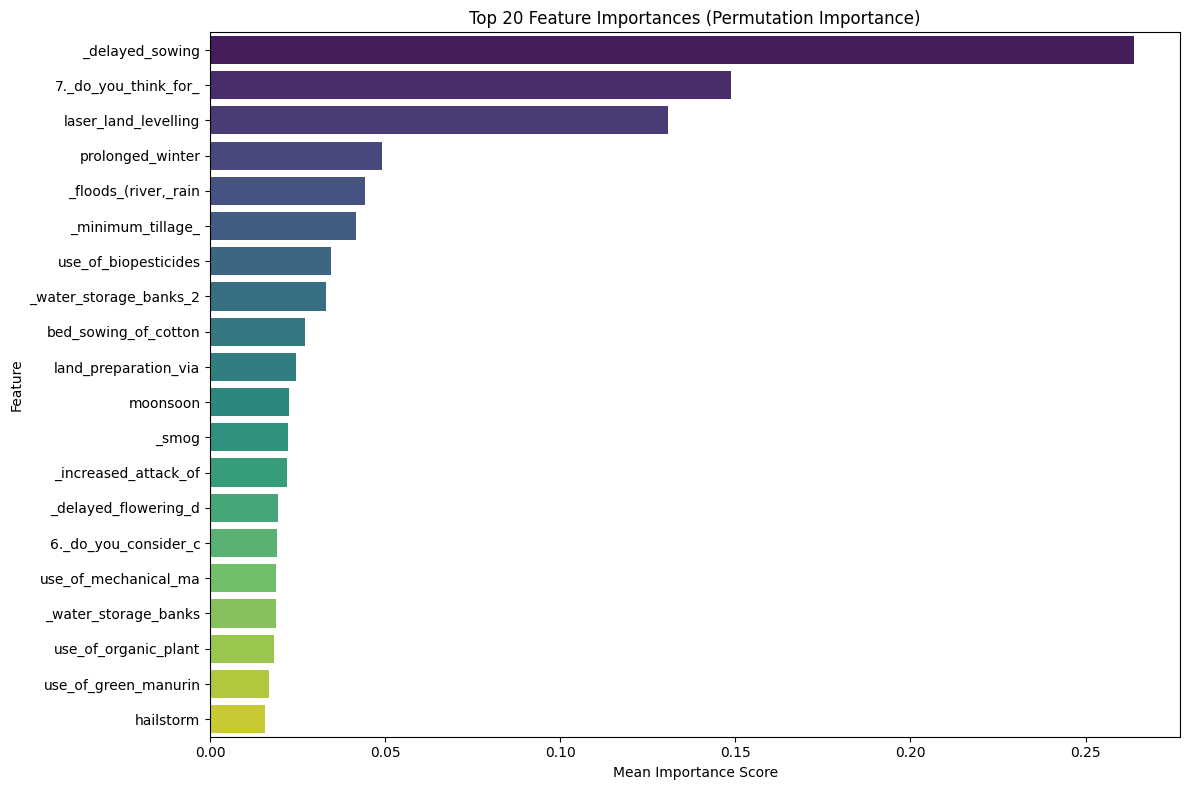

In [ ]:
# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Compute permutation importance
result = permutation_importance(model, X, y, n_repeats=10, random_state=42)
importances = result.importances_mean
feature_names = X.columns

# Create a DataFrame for better handling
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance and get top 20
top_features = importance_df.sort_values(by="Importance", ascending=False).head(20)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(x="Importance", y="Feature", data=top_features, palette="viridis")
plt.title("Top 20 Feature Importances (Permutation Importance)")
plt.xlabel("Mean Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# **Model Implimantation**

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Assuming your DataFrame is named 'df'
X = df.drop(['yield_of_cotton_per_', 'yield_of_cotton_per__2'], axis=1)
y = df[['yield_of_cotton_per_', 'yield_of_cotton_per__2']]

# Convert non-numeric columns to numeric, coercing errors to NaN
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        X[col] = pd.to_numeric(X[col], errors='coerce')
for col in y.columns:
    if not pd.api.types.is_numeric_dtype(y[col]):
        y[col] = pd.to_numeric(y[col], errors='coerce')

# Handle missing values (e.g., imputation or removal)
X = X.fillna(X.mean())  # Example: Impute with mean
y = y.fillna(y.mean())

# Scale the data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y)

**Rondom Forest**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Reshape X back to 2 dimensions before splitting and training
X = X.reshape(X.shape[0], -1)

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest Regressor for multi-output regression
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)


# Evaluation metrics
mse = mean_squared_error(y_test, y_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
r2 = r2_score(y_test, y_pred, multioutput='raw_values')

# Get the original column names from the DataFrame before scaling (df)
original_y_columns = df[['yield_of_cotton_per_', 'yield_of_cotton_per__2']].columns
#original_y_columns = df['yield_of_cotton_per__2']

# Print results for each target variable using original column names
for i, col in enumerate(original_y_columns):
    print(f"Metrics for target '{col}':")
    print(f"  RMSE: {rmse[i]:.4f}")
    print(f"  MAE : {mae[i]:.4f}")
    print(f"  R²  : {r2[i]:.4f}")
    print()

Metrics for target 'yield_of_cotton_per_':
  RMSE: 0.1500
  MAE : 0.1056
  R²  : 0.2679

Metrics for target 'yield_of_cotton_per__2':
  RMSE: 0.1361
  MAE : 0.0989
  R²  : 0.3833



In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

metrics_results = {}

# 📌 Function to Calculate RMSE, MAE, R²
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics_results[model_name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"📊 Performance of {model_name}:")
    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE: {mae:.4f}")
    print(f"✅ R² Score: {r2:.4f}")
    print("-" * 40)

# 📌 Evaluate LSTM Model
evaluate_model(y_test, y_pred, "Rondom Forest")


📊 Performance of Rondom Forest:
✅ RMSE: 0.1432
✅ MAE: 0.1023
✅ R² Score: 0.3256
----------------------------------------


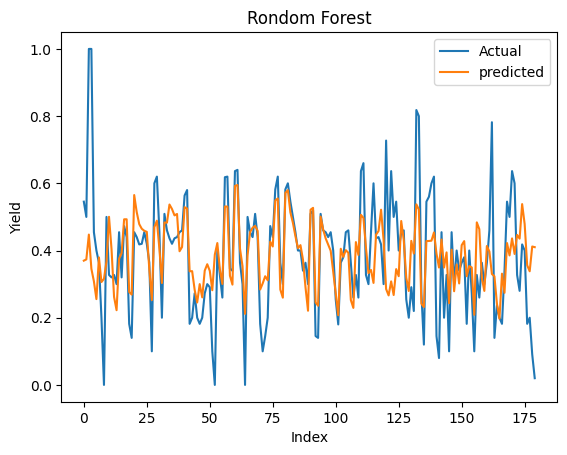

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_test_original = scaler_y.inverse_transform(y_test)
y_pred_original = scaler_y.inverse_transform(y_pred)

# Convert to 1D
y_test_flat = y_test.ravel()
y_pred_flat = y_pred.ravel()


# Plot 1
#axs[0, 0].plot(df['yield_of_cotton_per_1'], label='Yield of Cotton (Year 1)')  # Changed to axs[0, 0].plot()
plt.plot(y_test_flat, label='Actual') # Changed to axs[0, 0].plot()
plt.plot(y_pred_flat, label='predicted') # Changed to axs[0, 0].plot()
plt.gca().set_xlabel('Index')  # You might want to change this to a relevant time or category # Changed to axs[0, 0].set_xlabel()
plt.gca().set_ylabel('Yield')  # Changed to axs[0, 0].set_ylabel()
plt.gca().set_title('Rondom Forest') # Changed to axs[0, 0].set_title()
plt.legend()
plt.show()

📊 Performance of Random Forest:
✅ RMSE: 0.1432
✅ MAE: 0.1023
✅ R² Score: 0.3256
----------------------------------------


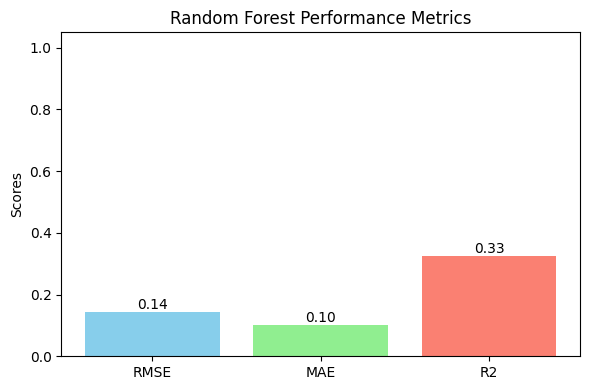

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

metrics_results = {}

# 📌 Function to Calculate RMSE, MAE, R²
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics_results[model_name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"📊 Performance of {model_name}:")
    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE: {mae:.4f}")
    print(f"✅ R² Score: {r2:.4f}")
    print("-" * 40)

# 📌 Example Evaluation (replace y_pred and y_test with actual data)
evaluate_model(y_test, y_pred, "Random Forest")

# 📊 Bar Graph for the evaluated model
model_name = "Random Forest"
metrics = metrics_results[model_name]
labels = list(metrics.keys())
values = list(metrics.values())
colors = ['skyblue', 'lightgreen', 'salmon']

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=colors)

# Add value labels on bars
for i in range(len(labels)):
    plt.text(i, values[i] + 0.01, f'{values[i]:.2f}', ha='center', fontsize=10)

plt.ylim(0, 1.05)
plt.title(f'{model_name} Performance Metrics')
plt.ylabel('Scores')
plt.tight_layout()
plt.show()


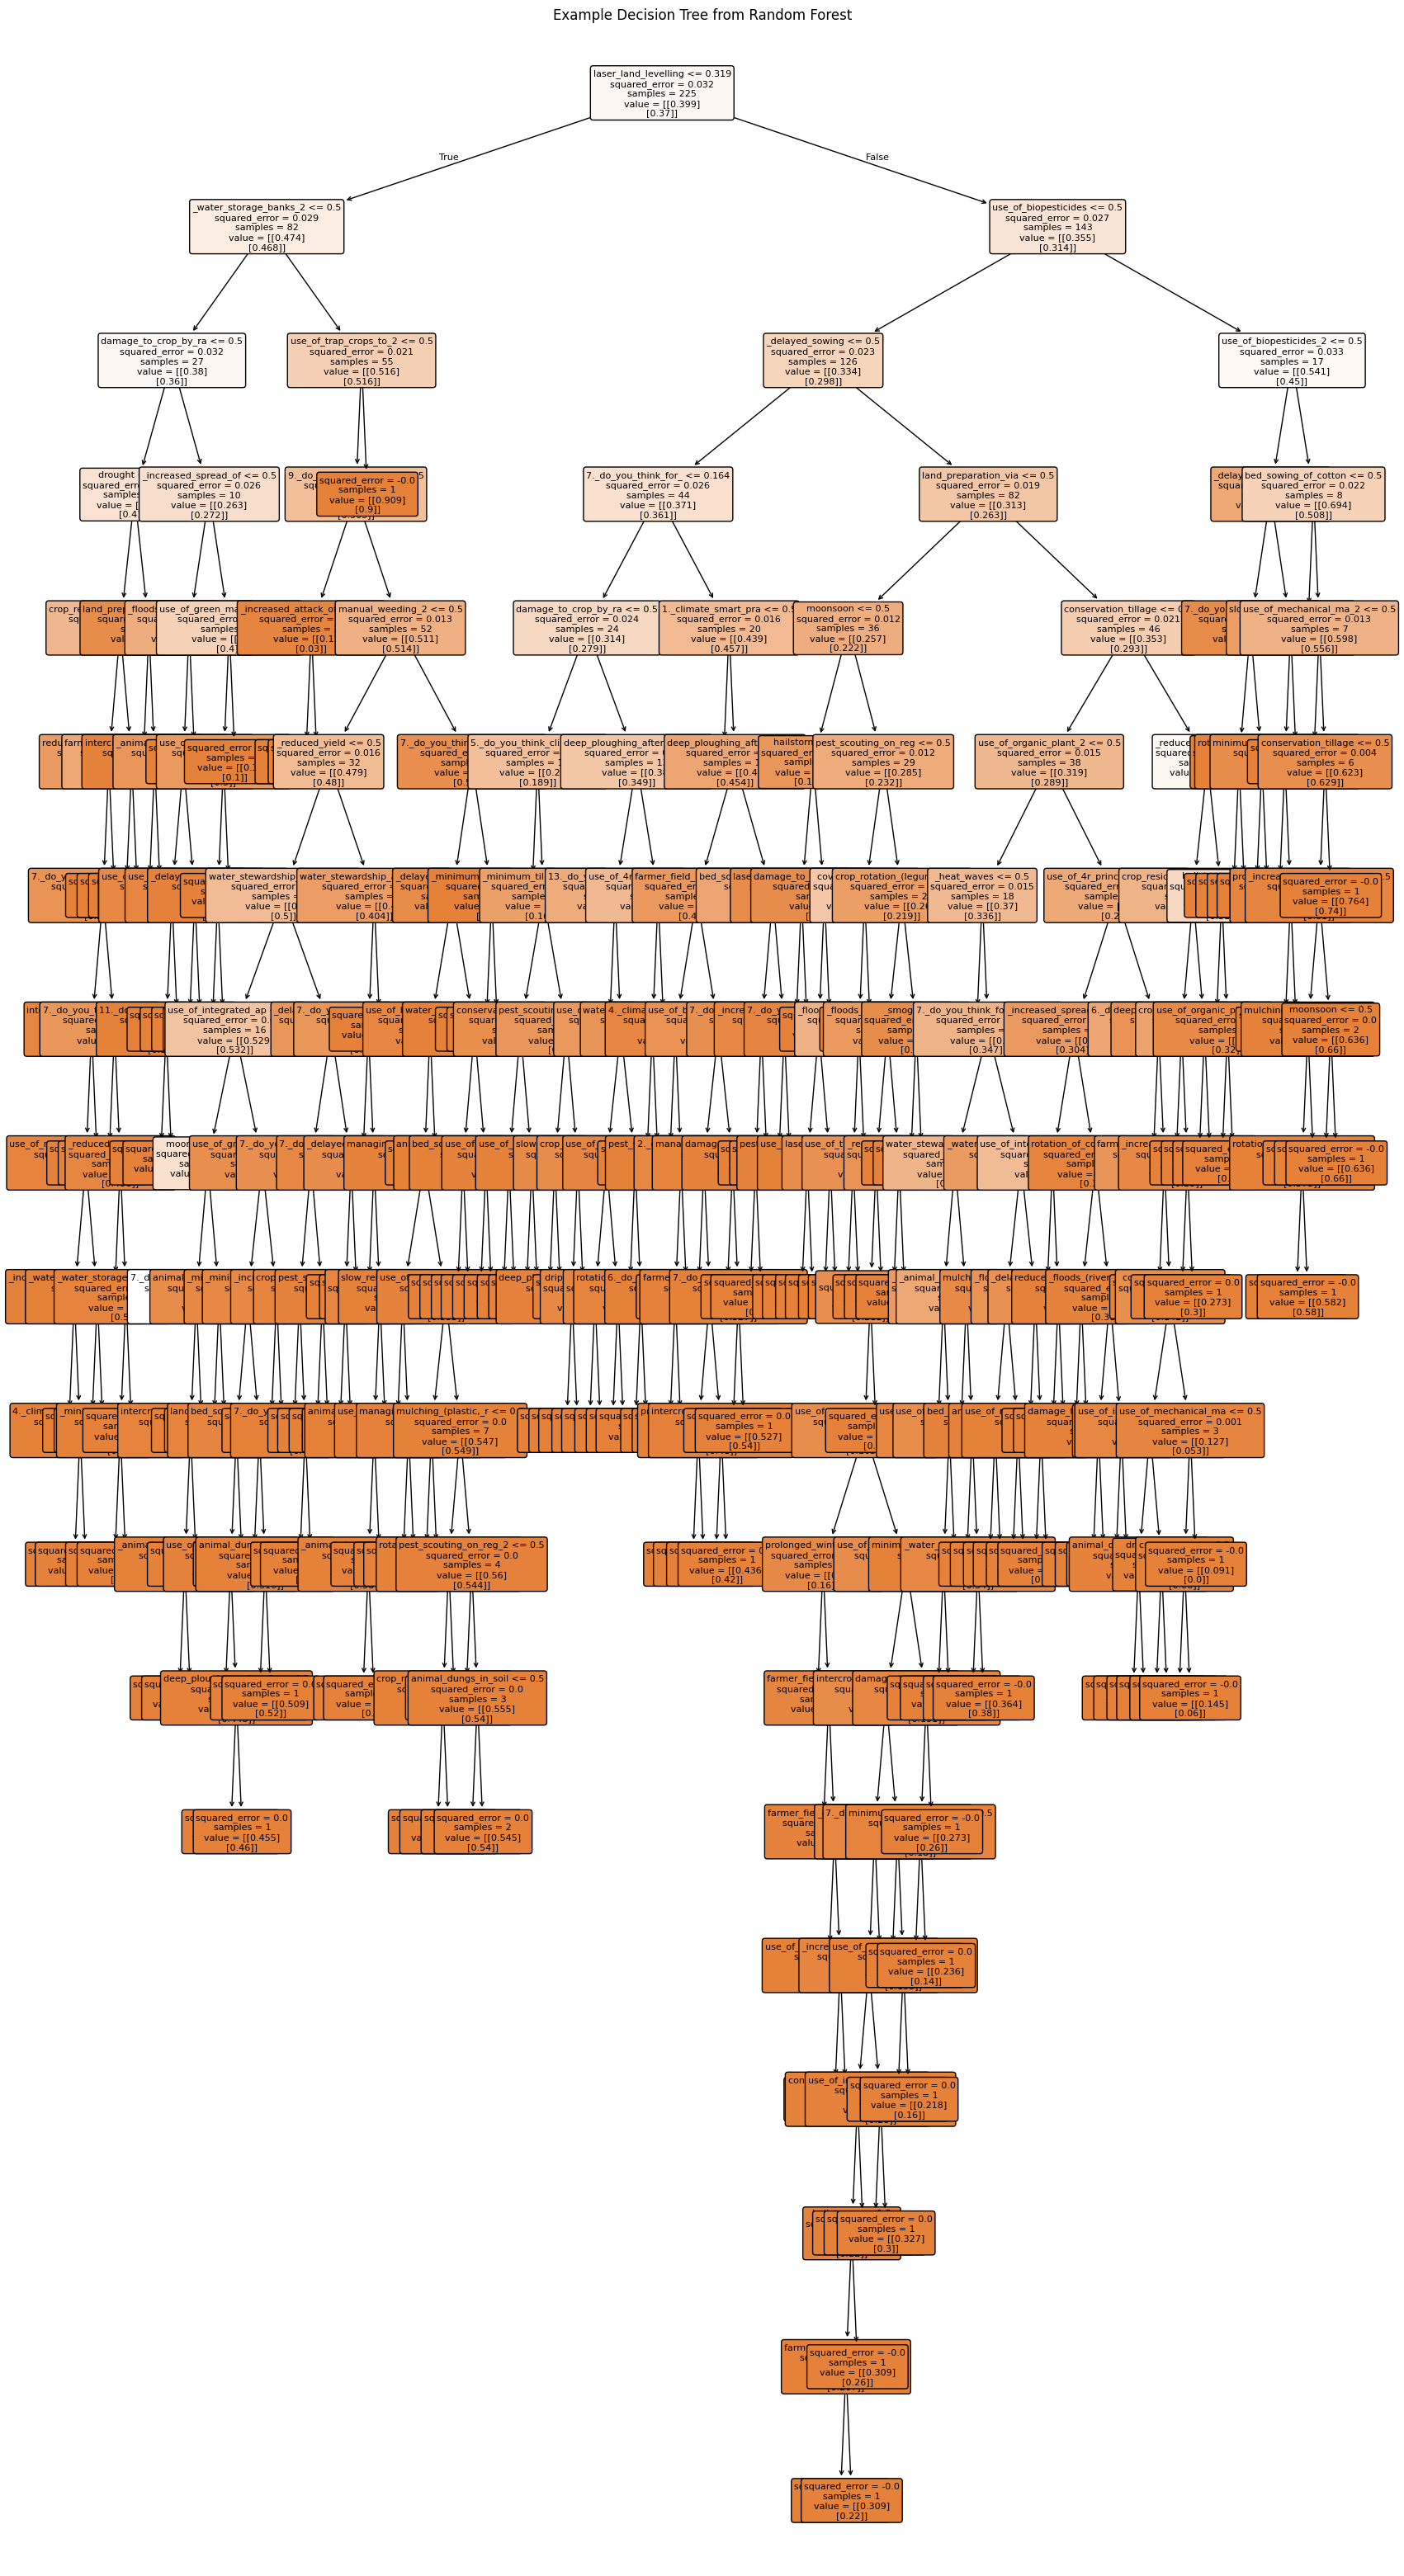

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Choose one tree to visualize (e.g., the first tree)
# Note: This is just one example tree and not representative of the entire forest's logic.
single_tree = model.estimators_[0]

plt.figure(figsize=(20, 40))
plot_tree(single_tree,
          feature_names=df.drop(['yield_of_cotton_per_', 'yield_of_cotton_per__2'], axis=1).columns,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Example Decision Tree from Random Forest")
plt.show()


# **RNN Models**

In [ ]:
import numpy as np

# Reshape input to be [samples, time steps, features]
X = X.reshape(X.shape[0], 1, X.shape[1])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dense

# LSTM
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model_lstm.add(Dense(units=2)) # 2 output units for 2 target variables
model_lstm.compile(loss='mse', optimizer='adam')
model_lstm.fit(X, y, epochs=100, batch_size=32)  # Adjust epochs and batch size

# Stacked LSTM
model_stacked_lstm = Sequential()
model_stacked_lstm.add(LSTM(units=50, activation='relu', return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model_stacked_lstm.add(LSTM(units=50, activation='relu'))
model_stacked_lstm.add(Dense(units=2))
model_stacked_lstm.compile(loss='mse', optimizer='adam')
model_stacked_lstm.fit(X, y, epochs=100, batch_size=32)

# Bidirectional LSTM
model_bidirectional_lstm = Sequential()
model_bidirectional_lstm.add(Bidirectional(LSTM(units=50, activation='relu'), input_shape=(X.shape[1], X.shape[2])))
model_bidirectional_lstm.add(Dense(units=2))
model_bidirectional_lstm.compile(loss='mse', optimizer='adam')
model_bidirectional_lstm.fit(X, y, epochs=100, batch_size=32)

# GRU
model_gru = Sequential()
model_gru.add(GRU(units=50, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model_gru.add(Dense(units=2))
model_gru.compile(loss='mse', optimizer='adam')
model_gru.fit(X, y, epochs=100, batch_size=32)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1360
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0435 
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0295 
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0276 
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0266 
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0241 
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0235 
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0210 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0186 
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0197 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0162 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0170 
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0185 
Ep

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0898
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0363
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0278
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0236
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0258
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0209
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0196
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0227
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0199
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0174 
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0150
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0143 
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0139 
Epoch 14/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0134 
Epoch 15/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0118 
Epoch 16/

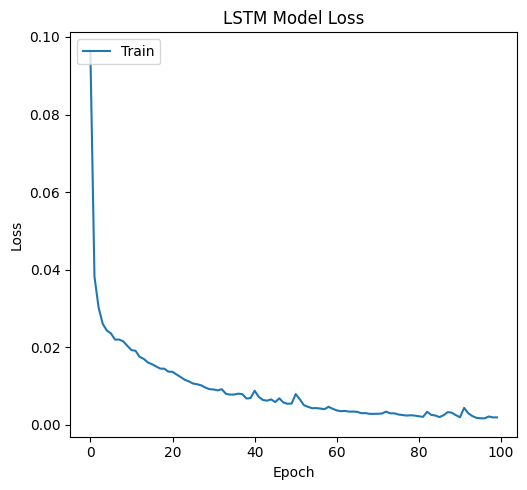

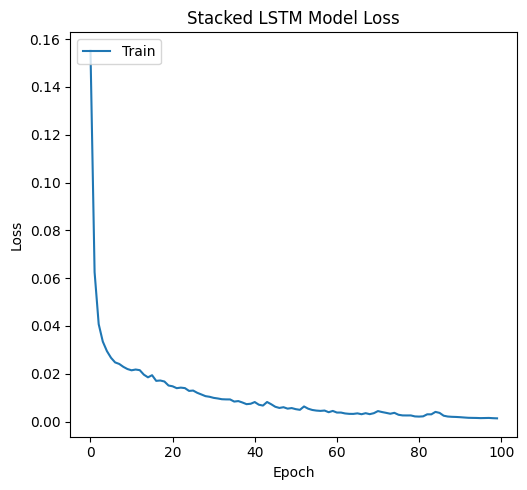

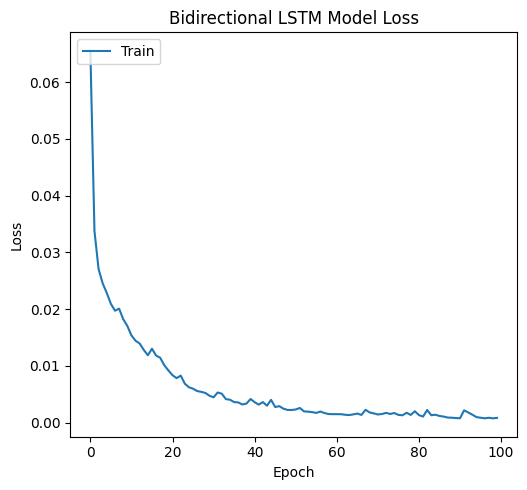

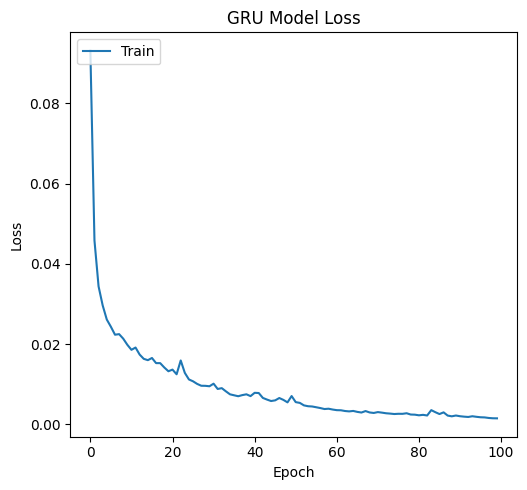

In [ ]:
def plot_model_history(history, model_name):
    plt.figure(figsize=(10, 5))

    # Plot training & validation accuracy values
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'])
    plt.title(f'{model_name} Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train'], loc='upper left')


    plt.tight_layout()
    plt.show()


# Example usage (assuming you have history objects):
plot_model_history(model_lstm.history, "LSTM")
plot_model_history(model_stacked_lstm.history, "Stacked LSTM")
plot_model_history(model_bidirectional_lstm.history, "Bidirectional LSTM")
plot_model_history(model_gru.history, "GRU")


In [ ]:
from sklearn.metrics import mean_squared_error

# Example: Evaluate LSTM model
lstmy_pred = model_lstm.predict(X)
stkdy_pred = model_stacked_lstm.predict(X)
bidy_pred = model_bidirectional_lstm.predict(X)
gruy_pred = model_gru.predict(X)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

metrics_results = {}

# 📌 Function to Calculate RMSE, MAE, R²
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    metrics_results[model_name] = {"RMSE": rmse, "MAE": mae, "R2": r2}

    print(f"📊 Performance of {model_name}:")
    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE: {mae:.4f}")
    print(f"✅ R² Score: {r2:.4f}")
    print("-" * 40)

# 📌 Evaluate LSTM Model
evaluate_model(y, lstmy_pred, "LSTM")

# 📌 Evaluate LSTM Model
evaluate_model(y, stkdy_pred, "Stacked LSTM")

# 📌 Evaluate Bi-LSTM Model
evaluate_model(y, bidy_pred, "Bidirectional LSTM")

# 📌 Evaluate GRU Model
evaluate_model(y, gruy_pred, "GRU")



📊 Performance of LSTM:
✅ RMSE: 0.0407
✅ MAE: 0.0267
✅ R² Score: 0.9472
----------------------------------------
📊 Performance of Stacked LSTM:
✅ RMSE: 0.0356
✅ MAE: 0.0227
✅ R² Score: 0.9602
----------------------------------------
📊 Performance of Bidirectional LSTM:
✅ RMSE: 0.0263
✅ MAE: 0.0146
✅ R² Score: 0.9782
----------------------------------------
📊 Performance of GRU:
✅ RMSE: 0.0375
✅ MAE: 0.0230
✅ R² Score: 0.9555
----------------------------------------


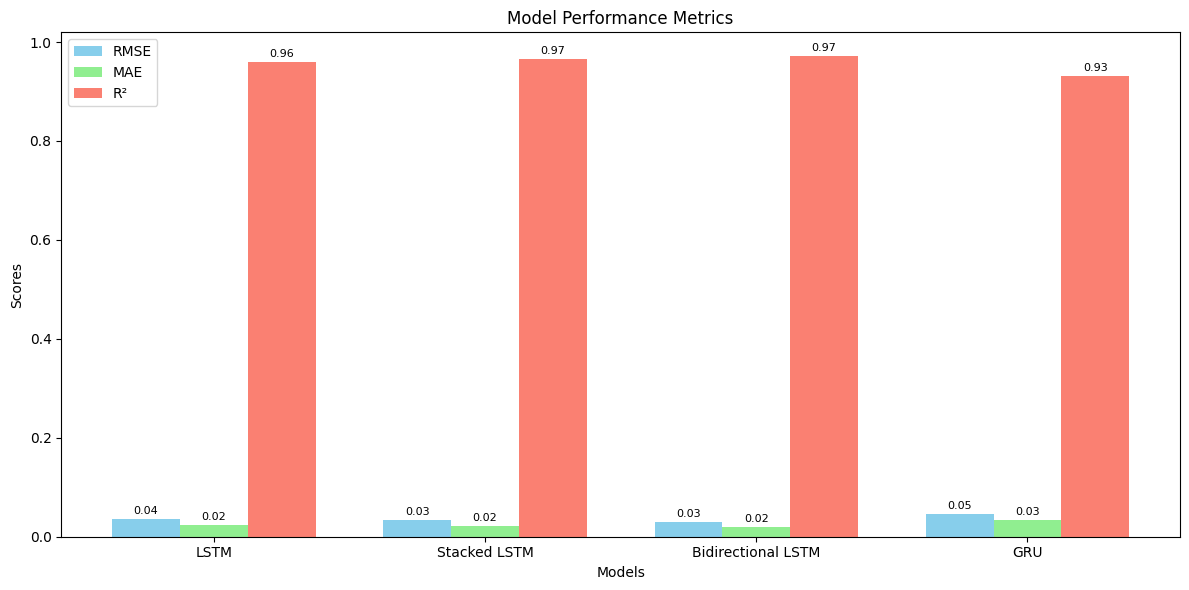

In [ ]:
# Plotting the results
model_names = list(metrics_results.keys())
rmse_vals = [metrics_results[m]["RMSE"] for m in model_names]
mae_vals = [metrics_results[m]["MAE"] for m in model_names]
r2_vals = [metrics_results[m]["R2"] for m in model_names]


x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, rmse_vals, width, label='RMSE', color='skyblue')
plt.bar(x, mae_vals, width, label='MAE', color='lightgreen')
plt.bar(x + width, r2_vals, width, label='R²', color='salmon')

plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Metrics')
plt.xticks(x, model_names)
plt.legend()

# Annotate bars
for i in range(len(model_names)):
    plt.text(x[i] - width, rmse_vals[i] + 0.01, f'{rmse_vals[i]:.2f}', ha='center', fontsize=8)
    plt.text(x[i], mae_vals[i] + 0.01, f'{mae_vals[i]:.2f}', ha='center', fontsize=8)
    plt.text(x[i] + width, r2_vals[i] + 0.01, f'{r2_vals[i]:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

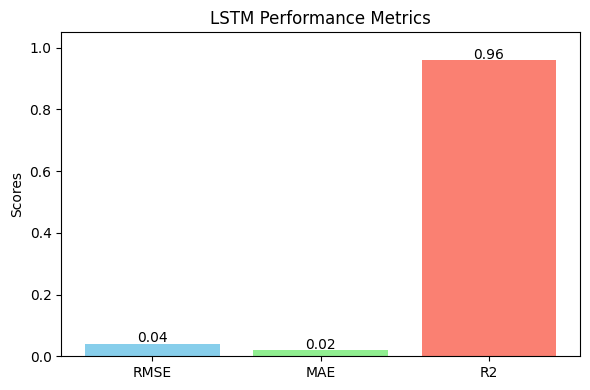

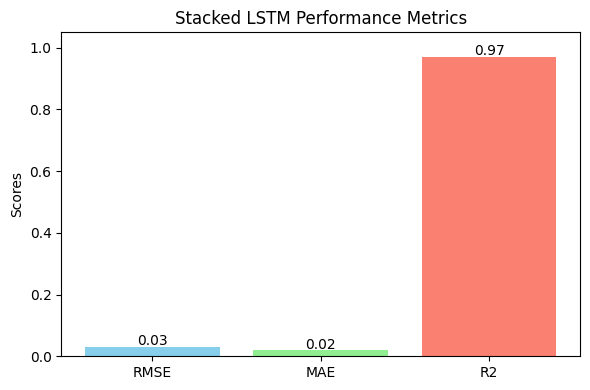

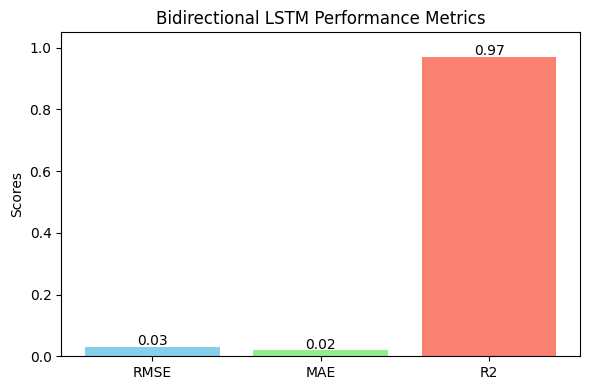

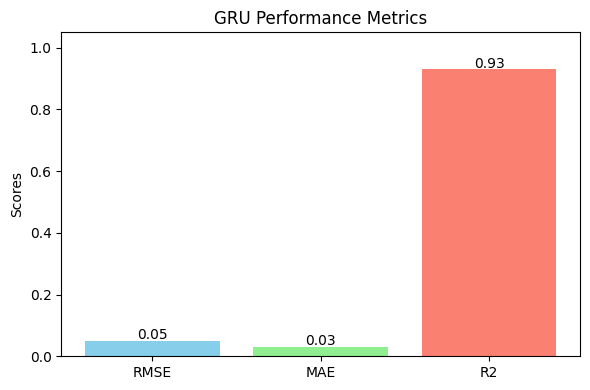

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dummy data (replace with your actual metrics_results dictionary)
metrics_results = {
    "LSTM": {"RMSE": 0.04, "MAE": 0.02, "R2": 0.96},
    "Stacked LSTM": {"RMSE": 0.03, "MAE": 0.02, "R2": 0.97},
    "Bidirectional LSTM": {"RMSE": 0.03, "MAE": 0.02, "R2": 0.97},
    "GRU": {"RMSE": 0.05, "MAE": 0.03, "R2": 0.93}
}

# Plot each model in a separate graph
for model_name, metrics in metrics_results.items():
    labels = list(metrics.keys())
    values = list(metrics.values())
    colors = ['skyblue', 'lightgreen', 'salmon']

    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=colors)

    # Add text labels above bars
    for i in range(len(labels)):
        plt.text(i, values[i] + 0.005, f'{values[i]:.2f}', ha='center', fontsize=10)

    plt.ylim(0, 1.05)
    plt.title(f'{model_name} Performance Metrics')
    plt.ylabel('Scores')
    plt.tight_layout()
    plt.show()


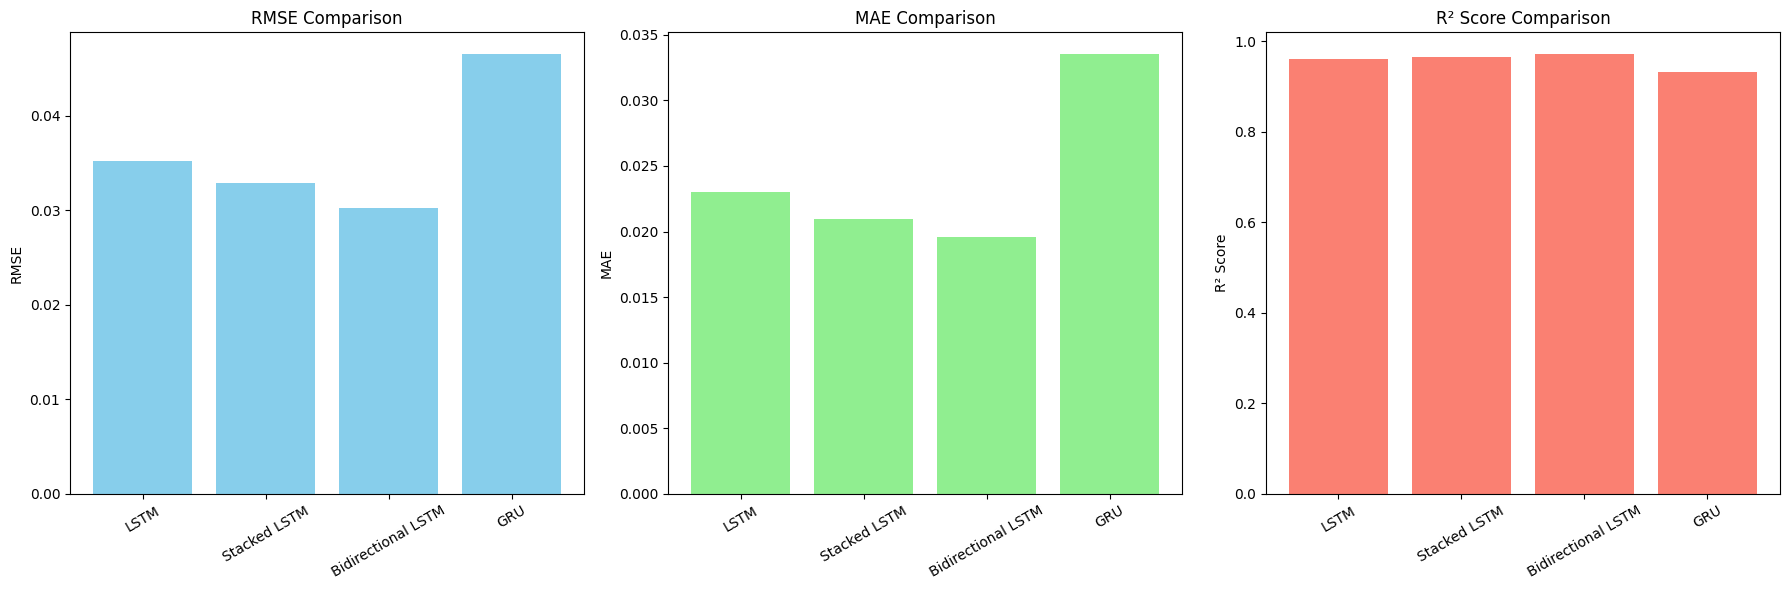

In [ ]:
# 📌 Create subplot layout
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# RMSE subplot
axs[0].bar(model_names, rmse_vals, color='skyblue')
axs[0].set_title("RMSE Comparison")
axs[0].set_ylabel("RMSE")
axs[0].tick_params(axis='x', rotation=30)

# MAE subplot
axs[1].bar(model_names, mae_vals, color='lightgreen')
axs[1].set_title("MAE Comparison")
axs[1].set_ylabel("MAE")
axs[1].tick_params(axis='x', rotation=30)

# R² subplot
axs[2].bar(model_names, r2_vals, color='salmon')
axs[2].set_title("R² Score Comparison")
axs[2].set_ylabel("R² Score")
axs[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
# Convert to 1D
y1d = y.ravel()
lstmy_pred = lstmy_pred.ravel()
stkdy_pred = stkdy_pred.ravel()
bidy_pred = bidy_pred.ravel()
gruy_pred = gruy_pred.ravel()

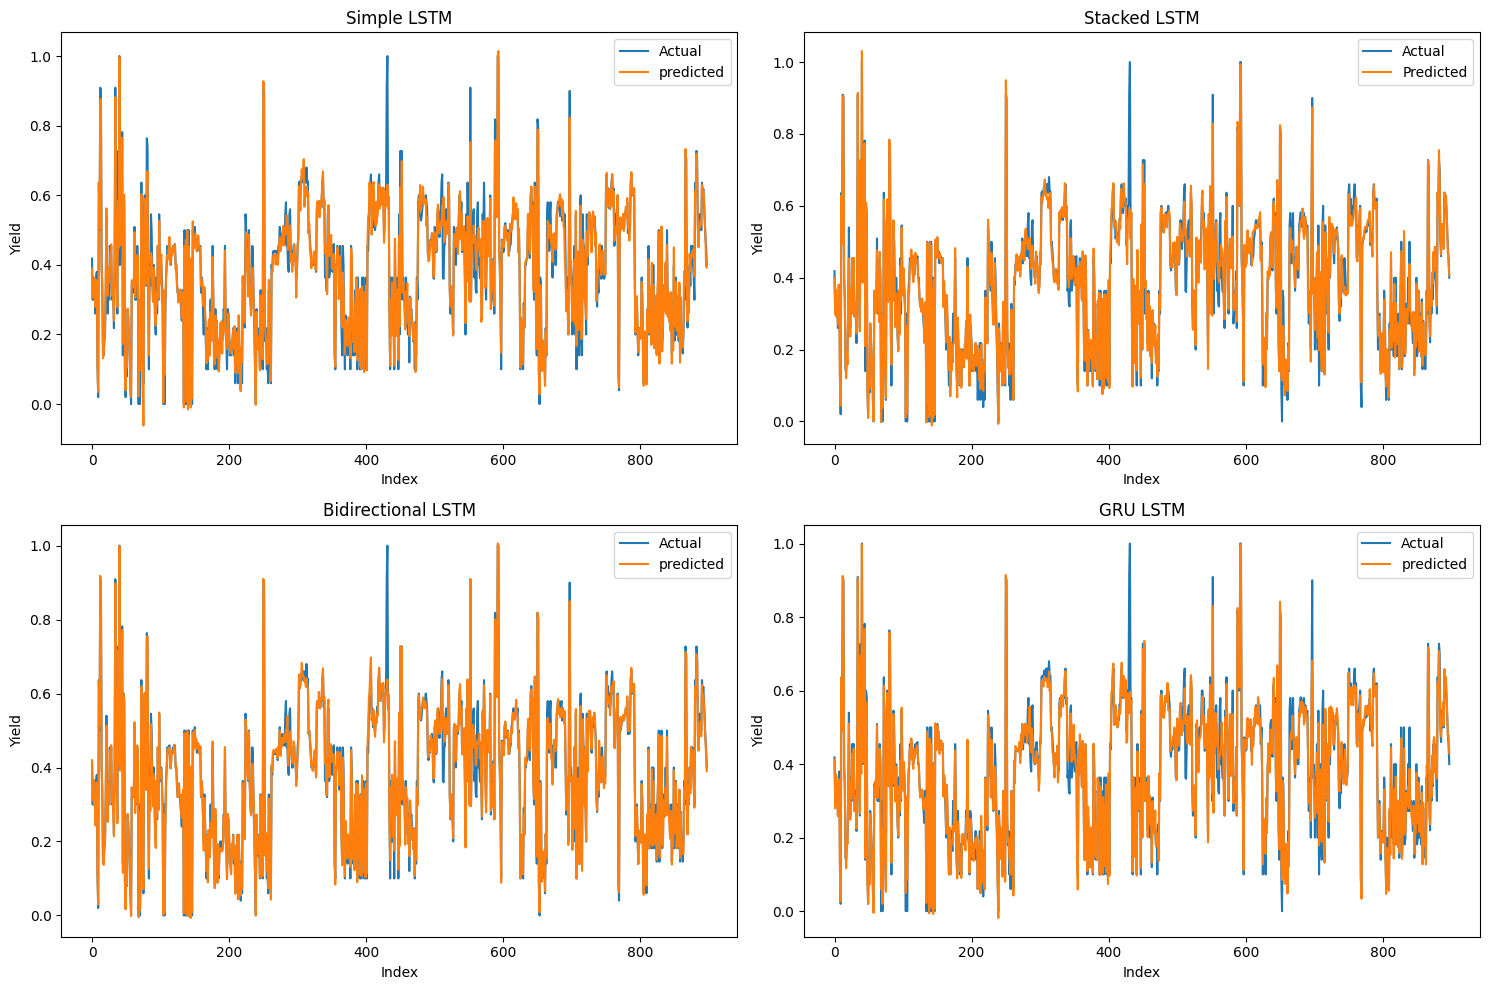

In [ ]:
import matplotlib.pyplot as plt

# Create 2x2 subplot
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1 - Simple LSTM
axs[0, 0].plot(y1d, label='Actual')
axs[0, 0].plot(lstmy_pred, label='predicted')
axs[0, 0].set_xlabel('Index')
axs[0, 0].set_ylabel('Yield')
axs[0, 0].set_title('Simple LSTM')
axs[0, 0].legend()

# Plot 2 - Stacked LSTM
axs[0, 1].plot(y1d, label='Actual')
axs[0, 1].plot(stkdy_pred, label='Predicted')
axs[0, 1].set_xlabel('Index')
axs[0, 1].set_ylabel('Yield')
axs[0, 1].set_title('Stacked LSTM')
axs[0, 1].legend()

# Plot 3 - Bidirectional LSTM
axs[1, 0].plot(y1d, label='Actual')
axs[1, 0].plot(bidy_pred, label='predicted')
axs[1, 0].set_xlabel('Index')
axs[1, 0].set_ylabel('Yield')
axs[1, 0].set_title('Bidirectional LSTM')
axs[1, 0].legend()

# Plot 4 - GRU LSTM
axs[1, 1].plot(y1d, label='Actual')
axs[1, 1].plot(gruy_pred, label='predicted')
axs[1, 1].set_xlabel('Index')
axs[1, 1].set_ylabel('Yield')
axs[1, 1].set_title('GRU LSTM')
axs[1, 1].legend()

# Adjust layout
plt.tight_layout()
plt.show()


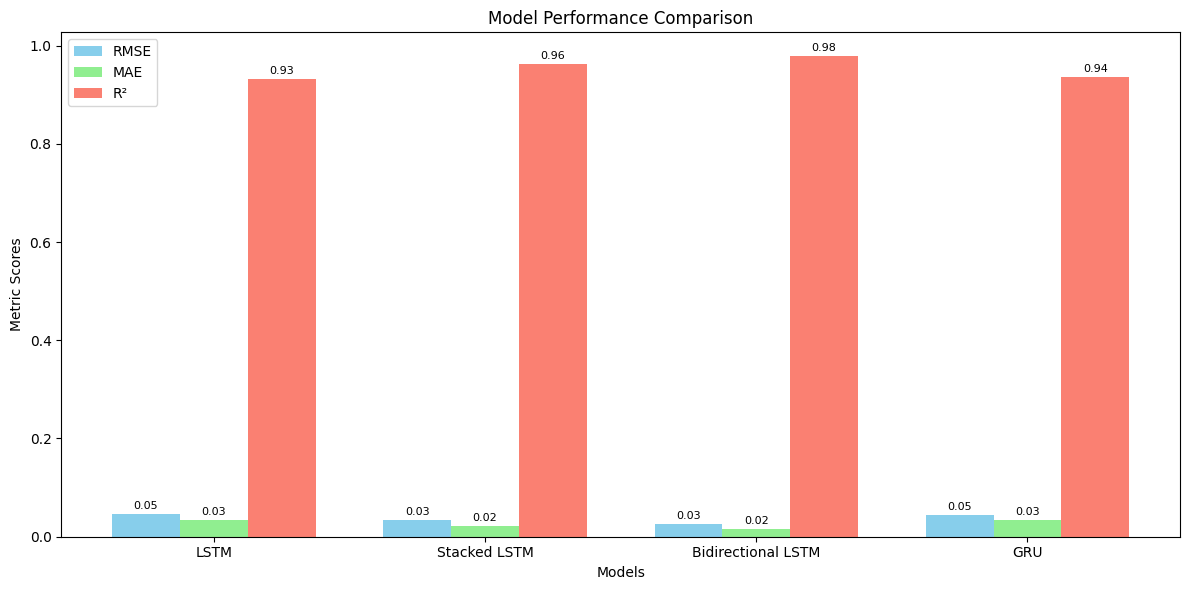

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to evaluate model and return metrics
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Model Names and Predictions
model_names = ['LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU']
predictions = [lstmy_pred, stkdy_pred, bidy_pred, gruy_pred]

# Evaluate all models
rmse_list, mae_list, r2_list = [], [], []

for pred in predictions:
    rmse, mae, r2 = evaluate_model(y, pred)
    rmse_list.append(rmse)
    mae_list.append(mae)
    r2_list.append(r2)

# Plotting grouped bar chart
x = np.arange(len(model_names))  # label locations
width = 0.25  # width of the bars

plt.figure(figsize=(12, 6))

# Bars for each metric
plt.bar(x - width, rmse_list, width, label='RMSE', color='skyblue')
plt.bar(x, mae_list, width, label='MAE', color='lightgreen')
plt.bar(x + width, r2_list, width, label='R²', color='salmon')

# Labels and Titles
plt.xlabel('Models')
plt.ylabel('Metric Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, model_names)
plt.legend()

# Annotate bars with values
for i in range(len(model_names)):
    plt.text(x[i] - width, rmse_list[i] + 0.01, f'{rmse_list[i]:.2f}', ha='center', fontsize=8)
    plt.text(x[i], mae_list[i] + 0.01, f'{mae_list[i]:.2f}', ha='center', fontsize=8)
    plt.text(x[i] + width, r2_list[i] + 0.01, f'{r2_list[i]:.2f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# prompt: Now Save prediction in excel file

# Assuming 'best_model_name' and predictions are available from the previous code

import pandas as pd
import numpy as np

# Create a dictionary to store the prediction results
prediction_data = {
    'Actual Yield (Year 2)': scaler_y.inverse_transform(y)[:,0],  # Inverse transform to get actual yield values #Added [:,0]
    'LSTM Predictions': scaler_y.inverse_transform(lstmy_pred)[:,0],
    'Stacked LSTM Predictions': scaler_y.inverse_transform(stkdy_pred)[:,0],
    'Bidirectional LSTM Predictions': scaler_y.inverse_transform(bidy_pred)[:,0],
    'GRU Predictions': scaler_y.inverse_transform(gruy_pred)[:,0],
    # 'Best Model': [best_model_name] * len(y) # Add a column indicating the best model
}

# Create a pandas DataFrame
predictions_df = pd.DataFrame(prediction_data)

#Best Model Predication
predictions_df['Best Model Predictions'] = np.nan  # Initialize with NaN
if best_model_name == "LSTM":
    predictions_df['Best Model Predictions'] = predictions_df['LSTM Predictions']
elif best_model_name == "Stacked LSTM":
    predictions_df['Best Model Predictions'] = predictions_df['Stacked LSTM Predictions']
elif best_model_name == "Bidirectional LSTM":
    predictions_df['Best Model Predictions'] = predictions_df['Bidirectional LSTM Predictions']
elif best_model_name == "GRU":
    predictions_df['Best Model Predictions'] = predictions_df['GRU Predictions']

# Add a column indicating the best model (after predictions are added)
predictions_df['Best Model'] = best_model_name

# Save to Excel
predictions_df.to_excel('cotton_yield_predictions.xlsx', index=False)

from google.colab import files
files.download('cotton_yield_predictions.xlsx')

**Save Model**

In [ ]:
# prompt: Now Save Prediction

import joblib

# Assuming 'best_model_name' holds the name of the best model
# and the corresponding model object is named accordingly (e.g., model_lstm)

if best_model_name == "LSTM":
    model_to_save = model_lstm
elif best_model_name == "Stacked LSTM":
    model_to_save = model_stacked_lstm
elif best_model_name == "Bidirectional LSTM":
    model_to_save = model_bidirectional_lstm
elif best_model_name == "GRU":
    model_to_save = model_gru
else:
    print("Error: Best model not found.")
    model_to_save = None

if model_to_save:
    filename = 'best_model.pkl'
    joblib.dump(model_to_save, filename)
    print(f"Model saved as {filename}")

    files.download(filename)


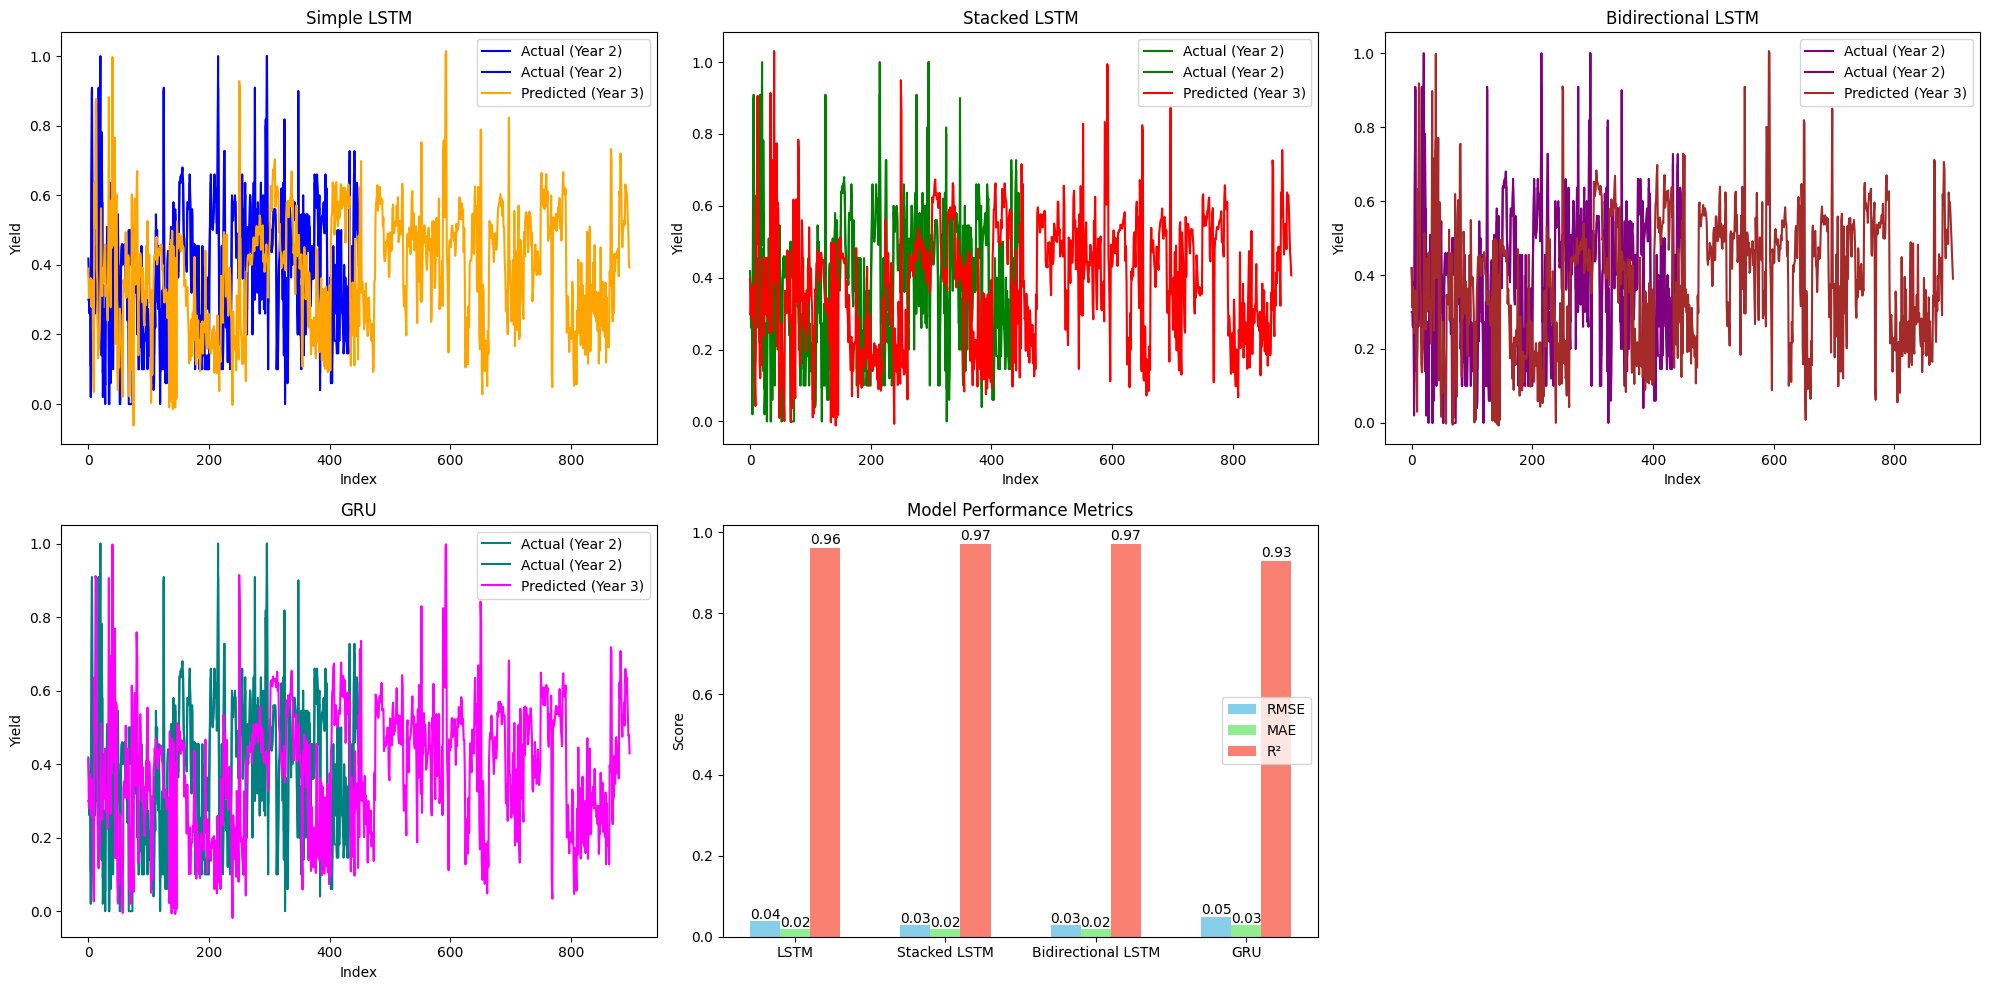

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dummy metrics (replace with your real values)
models = ['LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU']
rmse = [0.04, 0.03, 0.03, 0.05]
mae = [0.02, 0.02, 0.02, 0.03]
r2 = [0.96, 0.97, 0.97, 0.93]

# Create a 2x3 layout
fig, axs = plt.subplots(2, 3, figsize=(20, 10))

# Plot 1: Simple LSTM
axs[0, 0].plot(y, label='Actual (Year 2)', color='blue')
axs[0, 0].plot(lstmy_pred, label='Predicted (Year 3)', color='orange')
axs[0, 0].set_title('Simple LSTM')
axs[0, 0].set_xlabel('Index')
axs[0, 0].set_ylabel('Yield')
axs[0, 0].legend()

# Plot 2: Stacked LSTM
axs[0, 1].plot(y, label='Actual (Year 2)', color='green')
axs[0, 1].plot(stkdy_pred, label='Predicted (Year 3)', color='red')
axs[0, 1].set_title('Stacked LSTM')
axs[0, 1].set_xlabel('Index')
axs[0, 1].set_ylabel('Yield')
axs[0, 1].legend()

# Plot 3: Bidirectional LSTM
axs[0, 2].plot(y, label='Actual (Year 2)', color='purple')
axs[0, 2].plot(bidy_pred, label='Predicted (Year 3)', color='brown')
axs[0, 2].set_title('Bidirectional LSTM')
axs[0, 2].set_xlabel('Index')
axs[0, 2].set_ylabel('Yield')
axs[0, 2].legend()

# Plot 4: GRU
axs[1, 0].plot(y, label='Actual (Year 2)', color='teal')
axs[1, 0].plot(gruy_pred, label='Predicted (Year 3)', color='magenta')
axs[1, 0].set_title('GRU')
axs[1, 0].set_xlabel('Index')
axs[1, 0].set_ylabel('Yield')
axs[1, 0].legend()

# Plot 5: Bar chart of metrics
x = np.arange(len(models))
width = 0.2
axs[1, 1].bar(x - width, rmse, width, label='RMSE', color='skyblue')
axs[1, 1].bar(x, mae, width, label='MAE', color='lightgreen')
axs[1, 1].bar(x + width, r2, width, label='R²', color='salmon')

# Add labels on bars
for i in range(len(models)):
    axs[1, 1].text(x[i] - width, rmse[i] + 0.005, f'{rmse[i]:.2f}', ha='center')
    axs[1, 1].text(x[i], mae[i] + 0.005, f'{mae[i]:.2f}', ha='center')
    axs[1, 1].text(x[i] + width, r2[i] + 0.01, f'{r2[i]:.2f}', ha='center')

axs[1, 1].set_title('Model Performance Metrics')
axs[1, 1].set_xticks(x)
axs[1, 1].set_xticklabels(models)
axs[1, 1].set_ylabel('Score')
axs[1, 1].legend()

# Remove unused subplot (2nd row, 3rd column)
fig.delaxes(axs[1, 2])

# Improve layout
plt.tight_layout()
plt.show()


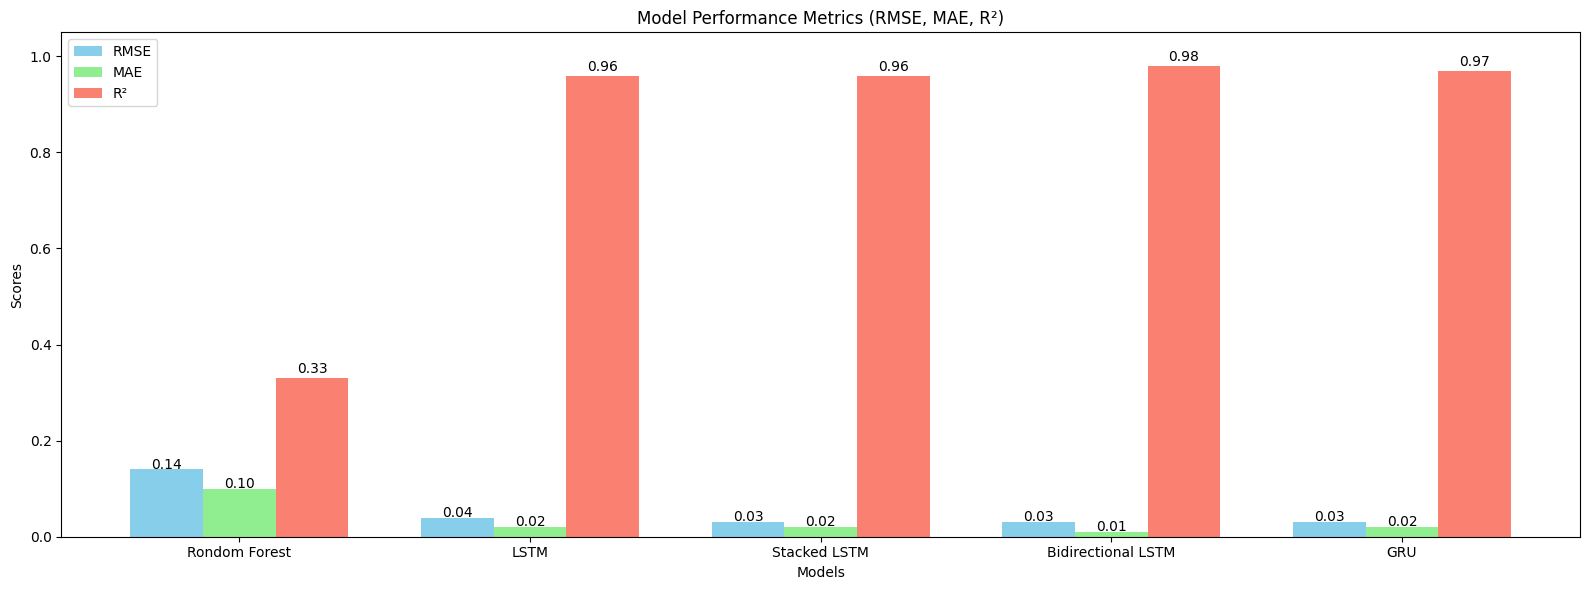

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Rondom Forest','LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU']  # <-- Add 5th model here

# Replace below with your actual data
rmse = [0.14, 0.04, 0.03, 0.03, 0.03]  # <-- add 5th value
mae =  [0.10, 0.02, 0.02, 0.01, 0.02]  # <-- add 5th value
r2 =   [0.33, 0.96, 0.96, 0.98, 0.97]  # <-- add 5th value

# Bar settings
x = np.arange(len(models))
width = 0.25

# Create plot
plt.figure(figsize=(16, 6))

# Plot bars
plt.bar(x - width, rmse, width, label='RMSE', color='skyblue')
plt.bar(x, mae, width, label='MAE', color='lightgreen')
plt.bar(x + width, r2, width, label='R²', color='salmon')

# Add value labels
for i in range(len(models)):
    plt.text(x[i] - width, rmse[i] + 0.002, f'{rmse[i]:.2f}', ha='center')
    plt.text(x[i], mae[i] + 0.002, f'{mae[i]:.2f}', ha='center')
    plt.text(x[i] + width, r2[i] + 0.01, f'{r2[i]:.2f}', ha='center')

# Labels and title
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Metrics (RMSE, MAE, R²)')
plt.xticks(x, models)
plt.ylim(0, 1.05)
plt.legend()

plt.tight_layout()
plt.show()


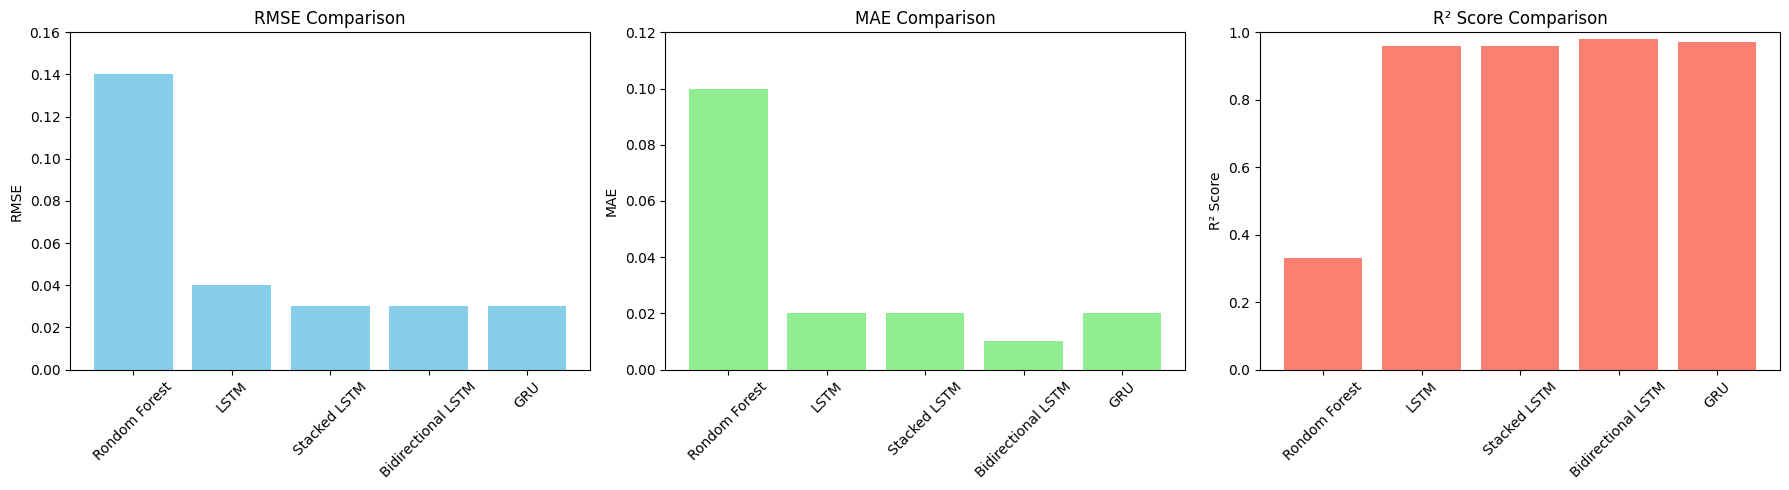

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Model names
models = ['Rondom Forest','LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU']  # <-- Add 5th model here
rmse = [0.14, 0.04, 0.03, 0.03, 0.03]  # <-- add 5th value
mae =  [0.10, 0.02, 0.02, 0.01, 0.02]  # <-- add 5th value
r2 =   [0.33, 0.96, 0.96, 0.98, 0.97]  # <-- add 5th value



# Plotting
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# RMSE
axs[0].bar(models, rmse, color='skyblue')
axs[0].set_title('RMSE Comparison')
axs[0].set_ylabel('RMSE')
axs[0].set_ylim(0, max(rmse) + 0.02)
axs[0].tick_params(axis='x', rotation=45)

# MAE
axs[1].bar(models, mae, color='lightgreen')
axs[1].set_title('MAE Comparison')
axs[1].set_ylabel('MAE')
axs[1].set_ylim(0, max(mae) + 0.02)
axs[1].tick_params(axis='x', rotation=45)

# R² Score
axs[2].bar(models, r2, color='salmon')
axs[2].set_title('R² Score Comparison')
axs[2].set_ylabel('R² Score')
axs[2].set_ylim(0, 1)
axs[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
